In [1]:
#1.import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
#2. Load Dataset
df = pd.read_csv('train.csv')

df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
#3. Understand Data Structure
print('column and row:',df.shape)
print('basic information:',df.info())
print('Statistical summary:',df.describe())
print('% missing number:',df.isnull().mean()*100)

column and row: (550068, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory u

In [4]:
# drop large missing column
df = df.dropna(subset=['Product_Category_2','Product_Category_3'])
print(df.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64


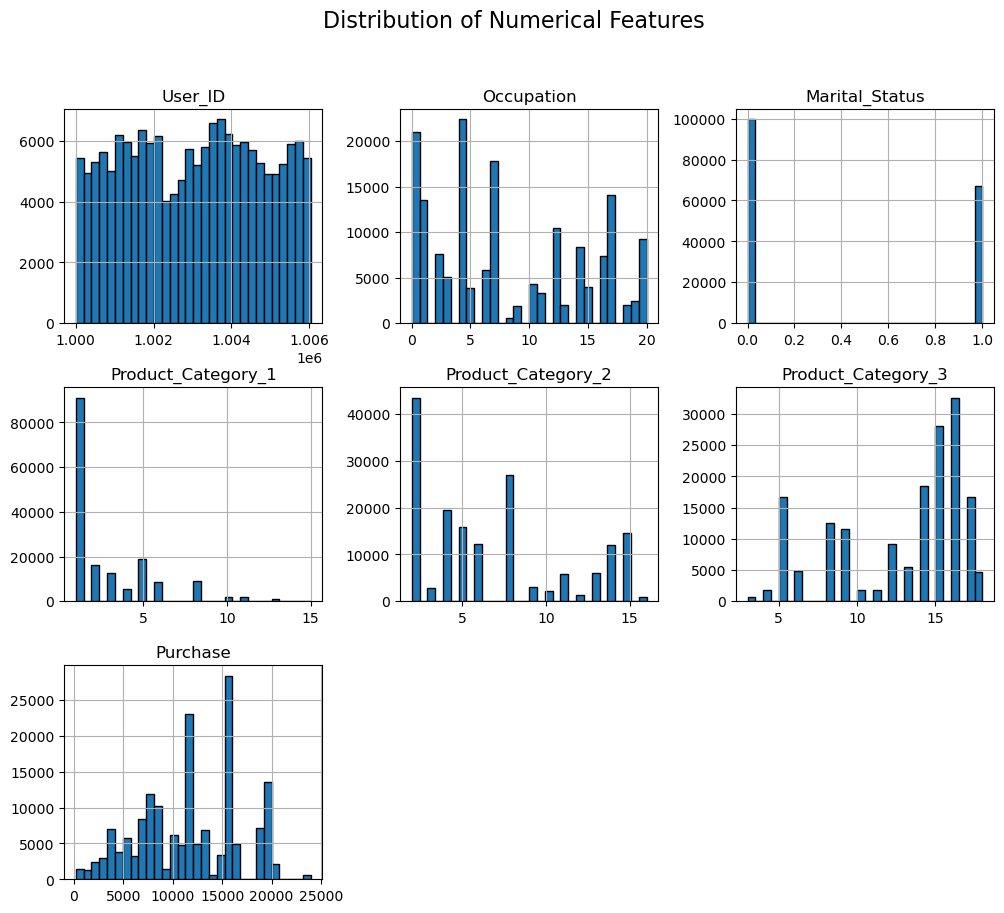

In [5]:
#4. feature analysis
#Histograms for Numerical columns
df.hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

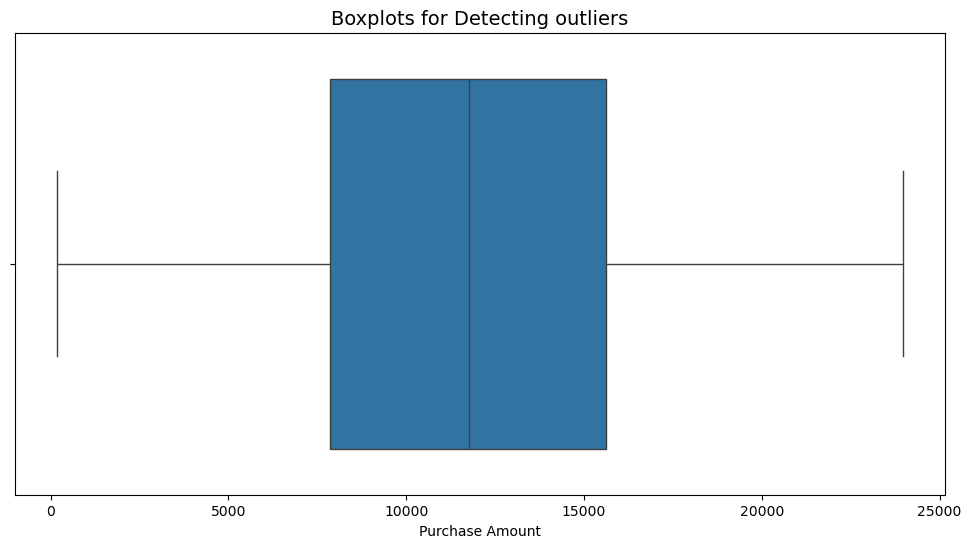

In [6]:
# detect outliers-box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Purchase'])
plt.title('Boxplots for Detecting outliers', fontsize=14)
plt.xlabel('Purchase Amount')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16412\558824481.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df_plot, palette='Set2', legend=False)


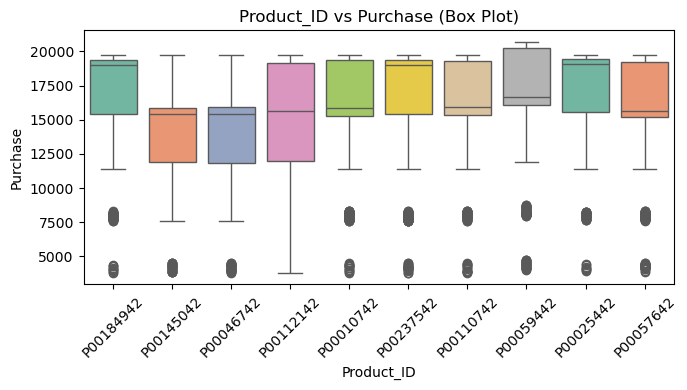

C:\Users\hp\AppData\Local\Temp\ipykernel_16412\558824481.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df_plot, palette='Set2', legend=False)


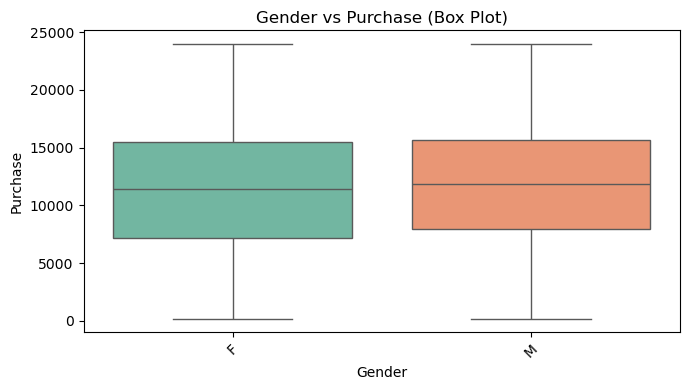

C:\Users\hp\AppData\Local\Temp\ipykernel_16412\558824481.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df_plot, palette='Set2', legend=False)


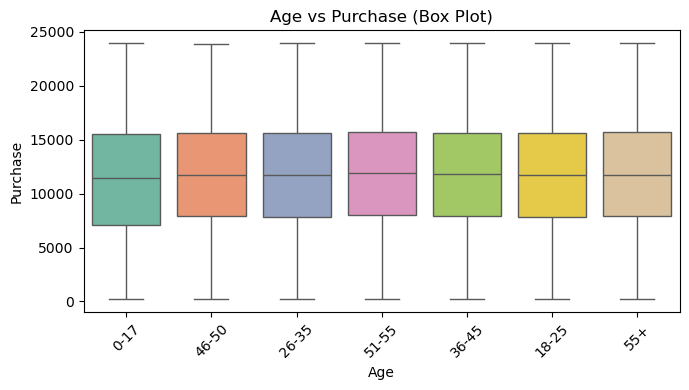

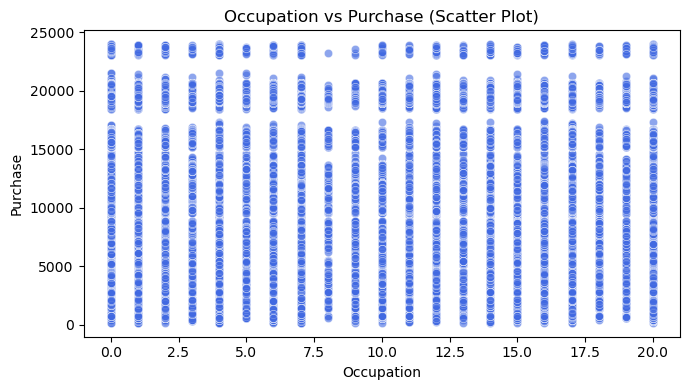

C:\Users\hp\AppData\Local\Temp\ipykernel_16412\558824481.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df_plot, palette='Set2', legend=False)


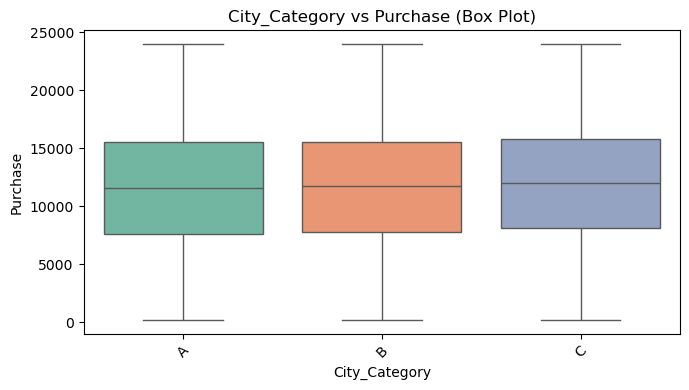

C:\Users\hp\AppData\Local\Temp\ipykernel_16412\558824481.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df_plot, palette='Set2', legend=False)


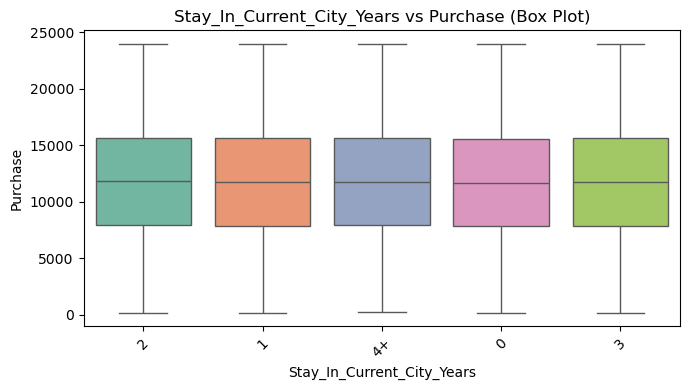

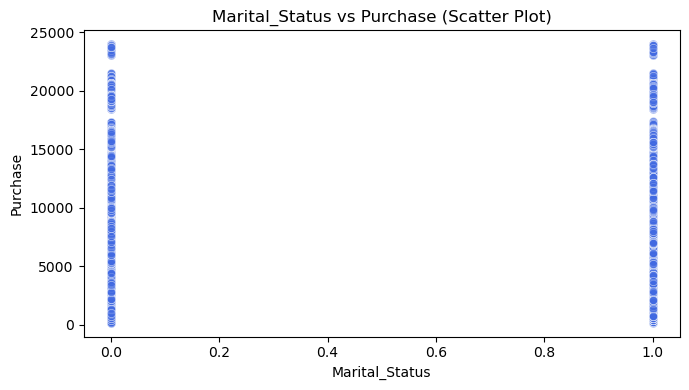

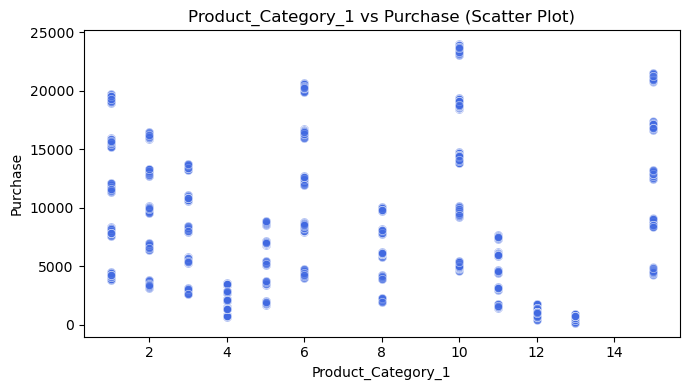

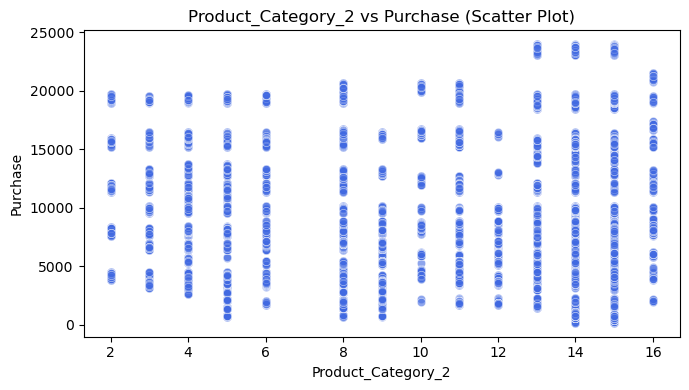

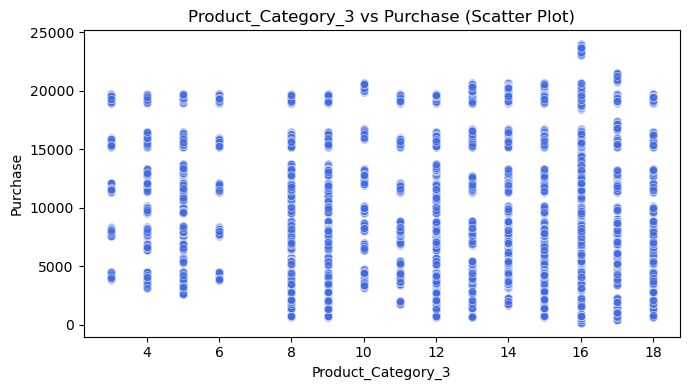

In [7]:
#5. Relationship between two variable

def plot_features_vs_purchase(df, target='Purchase'):
    """
    Automatically plots each variable in the dataset against the target (Purchase).
    - Numeric columns → scatter plots
    - Categorical columns → box plots
    """
    features = [col for col in df.columns if col not in [target, 'User_ID']]

    for col in features:
        plt.figure(figsize=(7, 4))

        if pd.api.types.is_numeric_dtype(df[col]):
            sns.scatterplot(x=df[col], y=df[target], alpha=0.6, color='royalblue')
            plt.title(f'{col} vs {target} (Scatter Plot)', fontsize=12)
            plt.xlabel(col)
            plt.ylabel(target)
        else:
            if df[col].nunique() > 10:
                top_categories = df[col].value_counts().index[:10]
                df_plot = df[df[col].isin(top_categories)]
            else:
                df_plot = df

            # 👇 Capital 'S' in 'Set2' fixes the error
            sns.boxplot(x=col, y=target, data=df_plot, palette='Set2', legend=False)
            plt.title(f'{col} vs {target} (Box Plot)', fontsize=12)
            plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()
plot_features_vs_purchase(df)

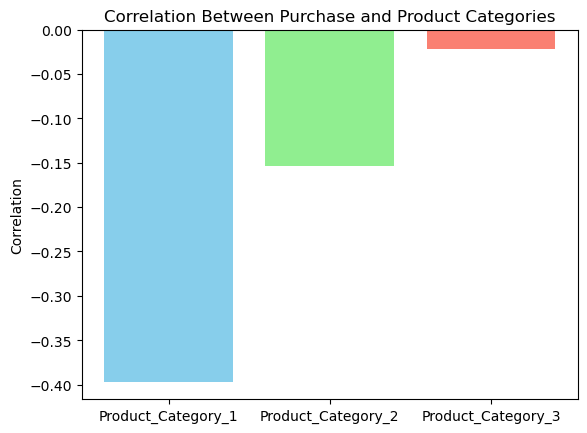

In [14]:
#6 Summary Comparison (Bar Chart of Means)

avg_purchases = {
    'Product_Category_1': df['Purchase'].corr(df['Product_Category_1']),
    'Product_Category_2': df['Purchase'].corr(df['Product_Category_2']),
    'Product_Category_3': df['Purchase'].corr(df['Product_Category_3']),
}

plt.bar(avg_purchases.keys(), avg_purchases.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Correlation Between Purchase and Product Categories')
plt.ylabel('Correlation')
plt.show()



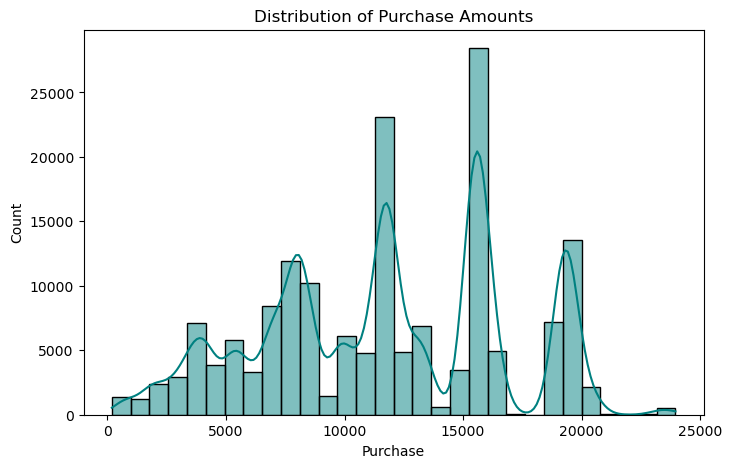

In [9]:
#Distribution Plots
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase'], bins=30, kde=True, color='teal')
plt.title('Distribution of Purchase Amounts')
plt.show()


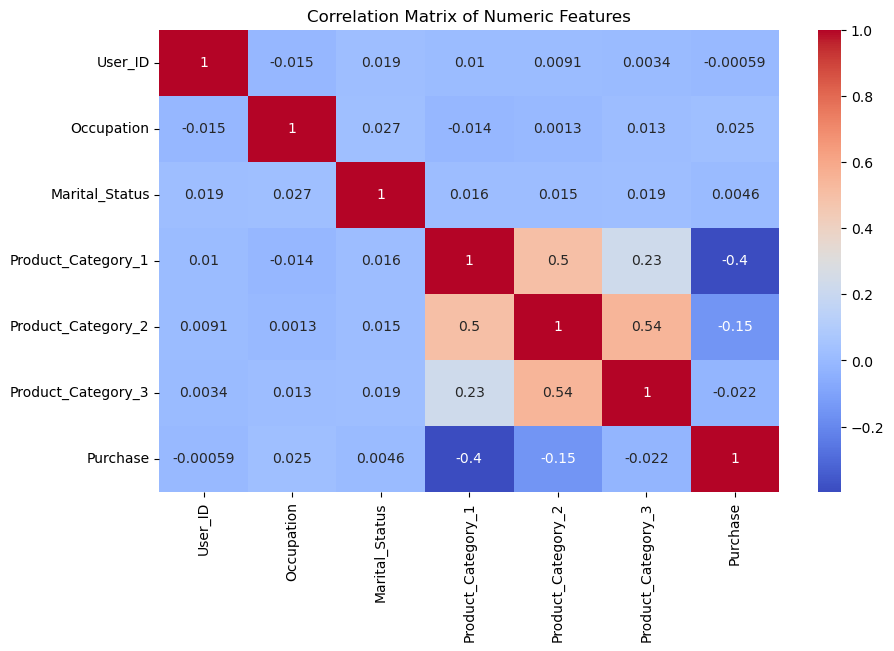

In [10]:
#Correlation Heatmap (Numerical Relationships)

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_16412\2483055745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Occupation', data=df, palette='Set2')


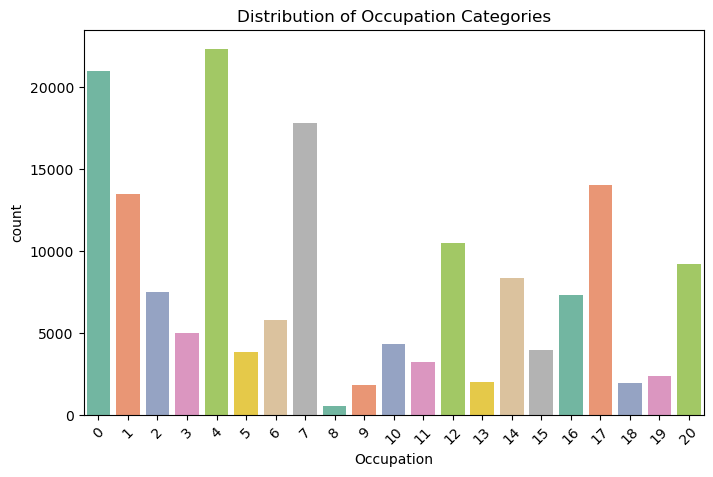

In [11]:
#Bar Charts for Categorical Features

plt.figure(figsize=(8,5))
sns.countplot(x='Occupation', data=df, palette='Set2')
plt.title('Distribution of Occupation Categories')
plt.xticks(rotation=45)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_16412\189592791.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Purchase', data=df, estimator='mean', palette='Set3')


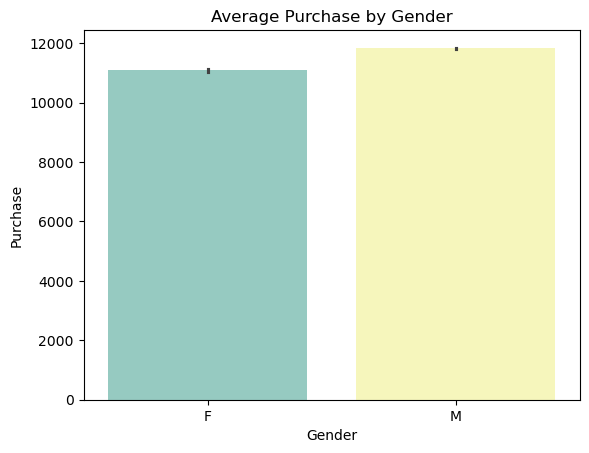

In [12]:
# Relationship across categories

sns.barplot(x='Gender', y='Purchase', data=df, estimator='mean', palette='Set3')
plt.title('Average Purchase by Gender')
plt.show()


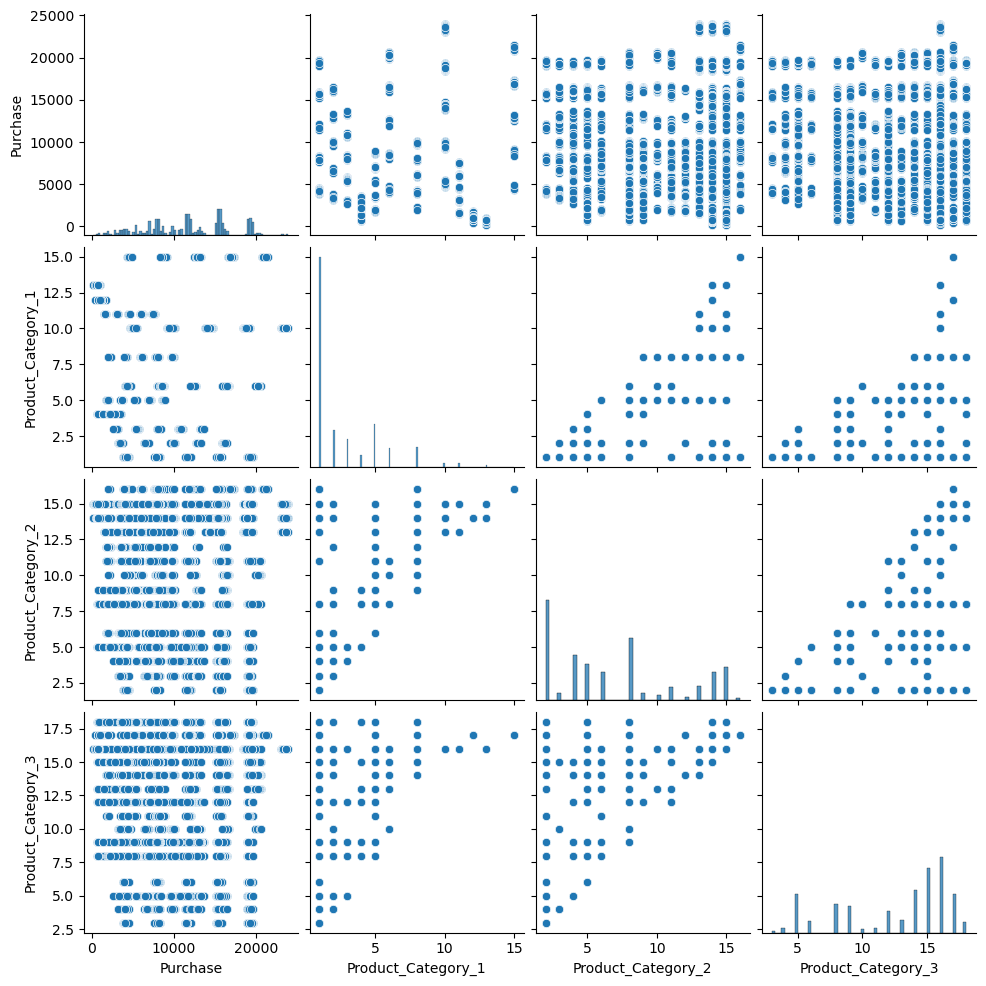

In [13]:
sns.pairplot(df[['Purchase', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']])
plt.show()


# Key EDA Insights

Purchase distribution is right-skewed (most customers spend less, few spend high amounts).

Product_Category_1 and Product_Category_3 have a moderate positive correlation with purchase.

Occupation 4 and 7 customers have the highest average purchases.

Male customers tend to spend slightly more than female customers.

Some extreme outliers exist in Purchase (> 25,000), which may represent high-value transactions.

# summary
1. import libraries
2. import dataset
3. understanding the data:
    Column and row: (550068, 12), Drop large dataset
4. Feature Analysis : no outlier
5. Relationship between two variable
6. Summary Comparison (Bar Chart of Means)